# Problem Set 2 - Andrew Koren

## Problem 1. Cyclotron

a) Circular motion in a uniform $\vec B$ field normal to $\vec v$ occurs for

$$
q v B = {mv^2 \over R} \Rightarrow R = {mv \over qB}
$$

The non-relativistic period $\tau$ is just the time to travel the circumference $\tau = {2\pi R \over v} = {2 \pi m \over qB} = {2\pi \over \omega_c}$.

If the particle is gaining velocity (small change), and the applied field $\vec B$ is constant, the radius will increase linearly with $v$ but the RF frequency can be fixed, as the transit time is constant for a cyclotron in this limit.

<!-- b) Note that $F = {d \vec p \over dt}$ -->

b)

$$
{d \vec p \over dt} \approx \gamma m {d \vec v\over dt} = \gamma m \vec a
$$
Centripedal acceleration is $\vec a = -{v^2 \over R} \hat r$, so we get our final answer

$$
{d \vec p \over dt} \approx -{m\gamma v^2 \over R} \hat r
$$

c) Length will contract as $R' = {R \over\gamma}$, so the "circumference" is effectively ${2\pi \gamma R}$ and the transit time is $\tau = {2 \pi \gamma R \over  v}$ in the rest frame. We insert kinetic energy as $\gamma = {\mathcal{E} \over mc^2} + 1$.

$$
\tau = {2 \pi \left( {\mathcal{E} \over mc^2} + 1 \right) R \over  v}
     = {2 \pi \over \omega_c} + {2 \pi \over \omega_c} {\mathcal{E} \over mc^2} 
$$

where $\omega_c$ is the non-relativistic frequency. The kinetic energy will grow even if velocity approaches $c$, so there is no longer a fixed transit time and circular motion cannot be sustained at high energies. The length grows faster than velocity rather than the linear result from earlier.

<div style="page-break-after: always">


## Problem 2. Thin Lens FODO Phase Advance and Stability

a) $\cos \Phi$ can be extracted as $\cos \Phi = {1 \over 2} \text{Tr}(M)$


In [45]:
from sympy import *

f, d, Phi = symbols('f L Phi', real=True, positive=True)

Focusing = Matrix([[1,0],[-1/f,1]])
Drift = Matrix([[1,d],[0,1]])
Defocusing = Matrix([[1,0],[1/f,1]])

print('beamline: FODO')

def step_by_step_mul(operations: list):
    '''
    Matrix multiplication (xf) = [On,On-1,...,O2,O1](xi)
    '''
    O_r = operations[-1]
    for i in range(-1, -len(operations), -1):
            display(simplify(MatMul(*operations[0:i],O_r)))
            O_r = operations[i-1]*O_r
    result = expand(O_r)
    display(result)
    return result

M = step_by_step_mul([Drift,Defocusing,Drift,Focusing])
print('1/2 Tr(M):')
display(Eq(cos(Phi), Abs(simplify((M[0,0]+M[1,1])/2))))

beamline: FODO


Matrix([
[1, L],
[0, 1]])*Matrix([
[  1, 0],
[1/f, 1]])*Matrix([
[1, L],
[0, 1]])*Matrix([
[   1, 0],
[-1/f, 1]])

Matrix([
[1, L],
[0, 1]])*Matrix([
[  1, 0],
[1/f, 1]])*Matrix([
[(-L + f)/f, L],
[      -1/f, 1]])

Matrix([
[1, L],
[0, 1]])*Matrix([
[(-L + f)/f,         L],
[   -L/f**2, (L + f)/f]])

Matrix([
[-L**2/f**2 - L/f + 1, L**2/f + 2*L],
[             -L/f**2,      L/f + 1]])

1/2 Tr(M):


Eq(cos(Phi), Abs(L**2/(2*f**2) - 1))

$$
-{L^2 \over 2 f^2} + 1 > -1
{L^2 \over 2 f^2} < 2
$$

This is stable as long as $\cos \Phi \in (-1, 1)$, which requires ${L^2 \over 2 f^2} < 2 \rightarrow f > L/2$

b) Based off the structure of the limit (the value instantly before $s=s_i$) will have the trajectory immediately pass through the first focusing lens. I tried solving the matricies for $f \lesssim L/2$ and $f \gtrsim L/2$ and found the key difference is crossing the $s$-axis ($x=0$) in the unstable case, which causes the focusing and subsequent defocusing magnet to kick the transverse motion in the same direction.

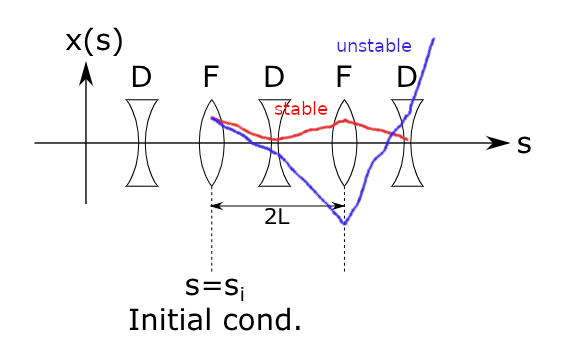
<!-- $$
\vec x_{s_i} = \begin{pmatrix} x_{s_i} \\ x_{s_i}' \end{pmatrix}  = M_F\vec x_{s_i^-} 
= \begin{bmatrix}
1 & 0 \\ -{1 \over f} & 1
\end{bmatrix} \begin{pmatrix} x_0 \\ x_0/L \end{pmatrix}
$$
this yields
$$
\vec x_{s_i} = \begin{pmatrix} x_0 \\ { x_0 \over L} - {x_0 \over L F} \end{pmatrix} = \begin{pmatrix} x_0 \\ { x_0 (f-1)\over Lf} \end{pmatrix}.
$$
After the drift:
$$
\vec x_{FO} = \begin{pmatrix} x_0 + { x_0 (f-1)\over f} \\ { x_0 (f-1)\over Lf} \end{pmatrix}.
$$
And the defocusing:
$$
\vec x_{FOD} = \begin{pmatrix} x_0 + { x_0 (f-1)\over f} \\ { x_0 (f-1)\over Lf} \end{pmatrix}.
$$ -->


In [56]:
x0 = symbols('x_0')
simplify((Drift*Focusing*Drift*Defocusing*Drift*Focusing*Matrix([x0, x0/d])).subs(f, d/3))

Matrix([
[   7*x_0],
[13*x_0/L]])

<div style="page-break-after: always">


## Problem 3. Drift Twiss Parameters

a) Collision point: smallest point of the beam $\alpha = 0$, also our transfer matrix is just the drift. 

<!-- $$
    \gamma_0 = {1 + \alpha_0^2 \over \beta_0}
\\  \gamma   = {1 \over \beta^*}
\\  0 = 
    - m_{21}m_{11} \beta_0 
    + m_{11}m_{22} \alpha_0
    + m_{12}m_{21} \alpha_0 
    - m_{12}m_{22} {1 + \alpha_0^2 \over \beta_0}
\\    \beta^* 
    = m_{11}^2 \beta_0 - 2m_{11}m_{12} \alpha_0 + m_{12}^2 {1 + \alpha_0^2 \over \beta_0}
\\  {1 \over \beta^*} = m_{21}^2 \beta_0 - 2 m_{22}m_{21} \alpha_0 + m_{22}^2 {1 + \alpha_0^2 \over \beta_0}
$$
 -->


In [77]:
S, C, Sp, Cp = symbols('S C S\' C\' ')
m11, m12, m21, m22 = symbols('m_{11:13} m_{21:23}')

Twiss_Propogation_Matrix = Matrix([
    [C*C, -2*S*C, S*S],
    [-C*Cp, Sp*C + S*C, -S*Sp],
    [Cp*Cp, -2*Sp*Cp, Sp*Sp]
    ])

def transfer_to_twiss(transfer_matrix):
    '''Twiss 1D Parameter Evolution Matrix'''

    [[a,b],[c,d]] = transfer_matrix.tolist()
    parameters = {
        C: a,
        S: b,
        Cp: c,
        Sp: d
        }
    result = Twiss_Propogation_Matrix.subs(parameters)
    return result.copy()

alpha, beta, beta_s, L = symbols('alpha beta beta^* s')
M = Matrix([[1,L],[0,1]])

gamma_0 = (1+alpha**2)/beta
gamma_s = 1/beta

twiss_s = Matrix([beta, alpha, gamma_0])
twiss_0 = Matrix([beta_s, 0, 1/beta_s])

display(Eq(symbols('M'), M, evaluate=False))
display(Eq(twiss_s, MatMul(transfer_to_twiss(M),twiss_0)))
display(Eq(twiss_s, MatMul(transfer_to_twiss(M),twiss_0)).doit())


Eq(M, Matrix([
[1, s],
[0, 1]]))

Eq(Matrix([
[               beta],
[              alpha],
[(alpha**2 + 1)/beta]]), Matrix([
[1,  -2*s, s**2],
[0, s + 1,   -s],
[0,     0,    1]])*Matrix([
[  beta^*],
[       0],
[1/beta^*]]))

Eq(Matrix([
[               beta],
[              alpha],
[(alpha**2 + 1)/beta]]), Matrix([
[beta^* + s**2/beta^*],
[           -s/beta^*],
[            1/beta^*]]))

Without loss of generality we use $s-s_0 \rightarrow s$

b) see above

c) see integral below, final step is by identity

$$
\begin{gathered}
    \psi(s) = \int_0^s {ds \over \beta(s)} = {{\beta^*} ds \over {\beta^*}^2 + s^2}
    = \tan^{-1}\left( s \over \beta^* \right)
\end{gathered}
$$

I also tried using my analytical package to get the answer:

In [93]:
betatron = MatMul(transfer_to_twiss(M),twiss_0).doit()[0]
integrate((beta_s/ (beta_s**2+L**2)), (L, 0, L))

I*log(-I*beta^*)/2 - I*log(I*beta^*)/2 - I*log(-I*beta^* + s)/2 + I*log(I*beta^* + s)/2

d) The range of $\tan^{-1}(x)$ is $(-\pi/2, \pi/2)$, which occurs for $s \rightarrow \infty$